In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import scipy.io as sio
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.metrics import confusion_matrix
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, BatchNormalization, Activation, Flatten, Dense, Dropout
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam


In [11]:
def build_1d_hsi_classifier(input_shape, num_classes):
    model = Sequential()

    # Warstwa konwolucyjna 1
    model.add(Conv1D(filters=32, kernel_size=3, padding='same', input_shape=(input_shape,1)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))

    # Warstwa konwolucyjna 2
    model.add(Conv1D(filters=64, kernel_size=3, padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))

    # Spłaszczenie
    model.add(Flatten())

    # Warstwa w pełni połączona 1
    model.add(Dense(128, activation='relu'))

    # Warstwa w pełni połączona 2 (warstwa wyjściowa)
    model.add(Dense(num_classes, activation='softmax'))

    # Kompilacja modelu
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

In [7]:
# Load data
data = sio.loadmat('../data/data/Indian_pines_NS_data.mat')
gt_data = sio.loadmat('../data/gt/Indian_pines_NS_gt.mat')

# Extract hyperspectral image and ground truth
hyper_image = data[list(data.keys())[-1]]  # Assuming last key contains data
ground_truth = gt_data[list(gt_data.keys())[-1]]  # Assuming last key contains ground truth
h, w, p = hyper_image.shape
print(hyper_image.shape)

reshaped_image = hyper_image.reshape(hyper_image.shape[0] * hyper_image.shape[1], hyper_image.shape[2])
reshaped_ground_truth = ground_truth.reshape(ground_truth.shape[0] * ground_truth.shape[1])


(2678, 614, 220)


In [34]:
class_counts = np.bincount(reshaped_ground_truth)
valid_classes = np.where(class_counts > 5000)[0]

mask = np.isin(reshaped_ground_truth, valid_classes)
reshaped_image = reshaped_image[mask]
reshaped_ground_truth = reshaped_ground_truth[mask]

# Remap labels to be sequential
unique_labels, remapped_labels = np.unique(reshaped_ground_truth, return_inverse=True)
num_classes = len(unique_labels)
print(num_classes)
y_one_hot = to_categorical(remapped_labels, num_classes=num_classes)



# Filter out pixels with no class (assuming class 0 is the "no class" label)
valid_indices = reshaped_ground_truth > 0
background_indices = reshaped_ground_truth == 0

# Downsample each class to a maximum of 5000 samples
filtered_image = []
filtered_labels = []

for class_label in range(num_classes):
    class_indices = np.where(remapped_labels == class_label)[0]
    if len(class_indices) > 5000:
        sampled_indices = resample(
            class_indices,
            n_samples=5000,
            random_state=42,
            replace=False
        )
    else:
        sampled_indices = class_indices

    filtered_image.append(reshaped_image[sampled_indices])
    filtered_labels.append(y_one_hot[sampled_indices])

# Combine all classes
filtered_image = np.vstack(filtered_image)
filtered_labels = np.vstack(filtered_labels)

X_train, X_test, y_train, y_test = train_test_split(filtered_image, filtered_labels, test_size=0.3, random_state=42)


18


Gradient Boosting Accuracy: 0.55


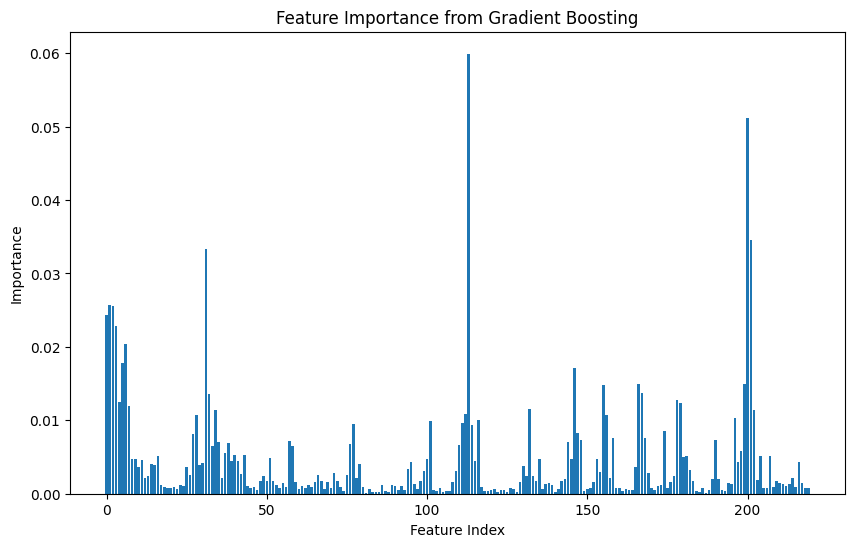

In [18]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Tworzenie modelu Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train.argmax(axis=1))  # Dopasowanie modelu (y_train w formie etykiet)

# Predykcja na zbiorze testowym
y_pred_gb = gb_model.predict(X_test)
print(f"Gradient Boosting Accuracy: {accuracy_score(y_test.argmax(axis=1), y_pred_gb):.2f}")

# Wyświetlenie znaczenia cech
feature_importances = gb_model.feature_importances_
plt.figure(figsize=(10, 6))
plt.bar(range(len(feature_importances)), feature_importances)
plt.xlabel('Feature Index')
plt.ylabel('Importance')
plt.title('Feature Importance from Gradient Boosting')
plt.show()

In [32]:


# Save feature importances to a .npy file
np.save("feature_importances.npy", feature_importances)

# Load the saved feature importances
loaded_feature_importances = np.load("feature_importances.npy")
print(loaded_feature_importances)

[0.02439022 0.02573836 0.02559139 0.02287448 0.01246065 0.01783166
 0.02035941 0.01195743 0.00466317 0.00472579 0.00362153 0.00460772
 0.00213223 0.00245616 0.00405659 0.00386154 0.00518583 0.00114822
 0.00093014 0.00082192 0.0007733  0.00085747 0.00060578 0.00117498
 0.00109281 0.00361223 0.0025372  0.00809428 0.01073399 0.00391022
 0.00418444 0.03332188 0.01351975 0.00644077 0.01137879 0.00706543
 0.0021354  0.00555291 0.00690608 0.00439402 0.00528025 0.004441
 0.00269743 0.00529038 0.00100508 0.00073038 0.00086693 0.0005628
 0.00177533 0.00238533 0.00173692 0.00484239 0.0017157  0.0011633
 0.00073784 0.00141607 0.0008493  0.00719177 0.00655746 0.00153257
 0.00070728 0.00106421 0.0007615  0.00118197 0.00096396 0.00163336
 0.00261174 0.00170027 0.00059418 0.00158928 0.00083231 0.00284209
 0.00170217 0.00096773 0.0003413  0.00254146 0.00677905 0.00952482
 0.00210188 0.00400612 0.00097884 0.00015295 0.00065308 0.00025426
 0.00019427 0.0002955  0.00114155 0.00040806 0.00023784 0.00114154

In [35]:
# Liczba najważniejszych kanałów do zachowania
top_k = 30  # Możesz zmienić tę wartość w zależności od potrzeb

# Znajdź indeksy top_k najważniejszych cech
top_indices = np.argsort(feature_importances)[-top_k:]

# Przytnij dane treningowe i testowe do tych kanałów
X_train_trimmed = X_train[:, top_indices]
X_test_trimmed = X_test[:, top_indices]

print(f"Nowy kształt X_train: {X_train_trimmed.shape}")
print(f"Nowy kształt X_test: {X_test_trimmed.shape}")

Nowy kształt X_train: (63000, 30)
Nowy kształt X_test: (27000, 30)


In [36]:

print(X_test_trimmed.shape)
print(X_train_trimmed.shape)

scaler = StandardScaler()
data_normalized = scaler.fit_transform(X_train_trimmed)

# PCA jako krok MNF
# pca = PCA(n_components=2)
# data_normalized = pca.fit_transform(data_normalized)
# X_test = pca.transform(X_test)



# scaler_post_PCA = StandardScaler()
# X_train = scaler_post_PCA.fit_transform(data_normalized)
X_test = scaler.transform(X_test_trimmed)

(27000, 30)
(63000, 30)


In [37]:
model = build_1d_hsi_classifier(X_train_trimmed.shape[1], num_classes)
history = model.fit(X_train_trimmed, y_train, epochs=100, batch_size=32, validation_split=0.2)
loss, accuracy = model.evaluate(X_test_trimmed, y_test)
print(f"Test Accuracy: {accuracy:.2f}")


Epoch 1/100


c:\Users\micha\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1575/1575 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1934 - loss: 2.5066 - val_accuracy: 0.2642 - val_loss: 2.2849
Epoch 2/100
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2718 - loss: 2.2114 - val_accuracy: 0.3092 - val_loss: 2.1223
Epoch 3/100
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3086 - loss: 2.0996 - val_accuracy: 0.3113 - val_loss: 2.0836
Epoch 4/100
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3208 - loss: 2.0491 - val_accuracy: 0.3381 - val_loss: 2.0026
Epoch 5/100
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3366 - loss: 2.0093 - val_accuracy: 0.3542 - val_loss: 1.9702
Epoch 6/100
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3416 - loss: 1.9890 - val_accuracy: 0.3533 - val_loss: 1.9925
Epoch 7/100
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3541 - loss: 1.9603 - val_accuracy: 0.3673 - val_loss: 1.9229
Epoch 8/100
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3676 - loss: 1.9341 - val_

In [38]:
X_train = X_train_trimmed
X_test = X_test_trimmed

1969/1969 ━━━━━━━━━━━━━━━━━━━━ 2s 936us/step
              precision    recall  f1-score   support

           0       0.52      0.17      0.25      3514
           1       0.56      0.66      0.61      3501
           2       0.38      0.19      0.26      3524
           3       0.28      0.25      0.26      3527
           4       0.29      0.47      0.36      3483
           5       0.29      0.22      0.25      3513
           6       0.57      0.45      0.50      3436
           7       0.66      0.47      0.55      3498
           8       0.64      0.82      0.72      3492
           9       0.72      0.68      0.70      3519
          10       0.50      0.43      0.46      3467
          11       0.35      0.63      0.45      3500
          12       0.40      0.58      0.47      3473
          13       0.43      0.28      0.34      3486
          14       0.41      0.26      0.32      3457
          15       0.64      0.73      0.68      3557
          16       0.53      0.79   

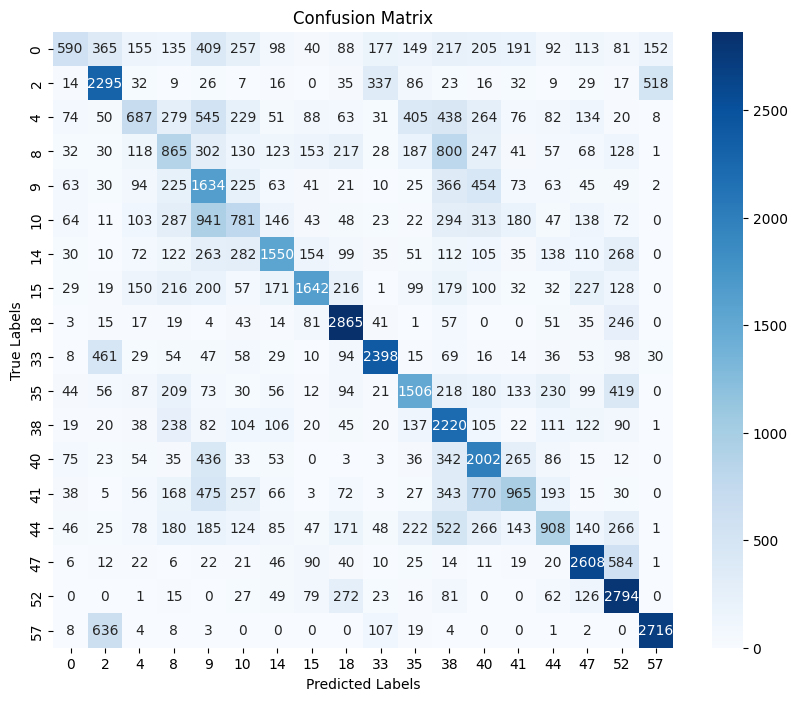

In [39]:
## TRAIN DATA
# 
y_pred = model.predict(X_train)
y_pred_classes = np.argmax(y_pred, axis=-1)
y_true_classes = np.argmax(y_train, axis=-1)
# Print classification report
print(classification_report(y_true_classes, y_pred_classes))

# Compute confusion matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=unique_labels, yticklabels=unique_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 920us/step
              precision    recall  f1-score   support

           0       0.52      0.17      0.25      1486
           1       0.56      0.67      0.61      1499
           2       0.33      0.17      0.23      1476
           3       0.25      0.23      0.24      1473
           4       0.28      0.46      0.35      1517
           5       0.28      0.22      0.24      1487
           6       0.58      0.44      0.50      1564
           7       0.65      0.47      0.55      1502
           8       0.66      0.80      0.72      1508
           9       0.73      0.67      0.70      1481
          10       0.51      0.43      0.46      1533
          11       0.33      0.63      0.44      1500
          12       0.39      0.57      0.46      1527
          13       0.41      0.25      0.31      1514
          14       0.39      0.25      0.31      1543
          15       0.61      0.71      0.66      1443
          16       0.50      0.77     

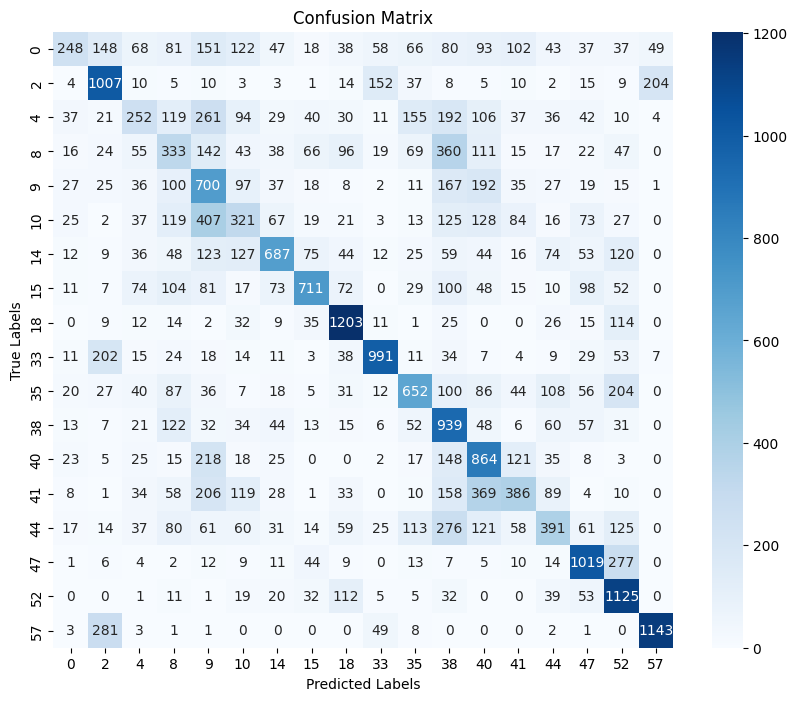

In [40]:
# Generate classification report
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=-1)
y_true_classes = np.argmax(y_test, axis=-1)
# Print classification report
print(classification_report(y_true_classes, y_pred_classes))

# Compute confusion matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=unique_labels, yticklabels=unique_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

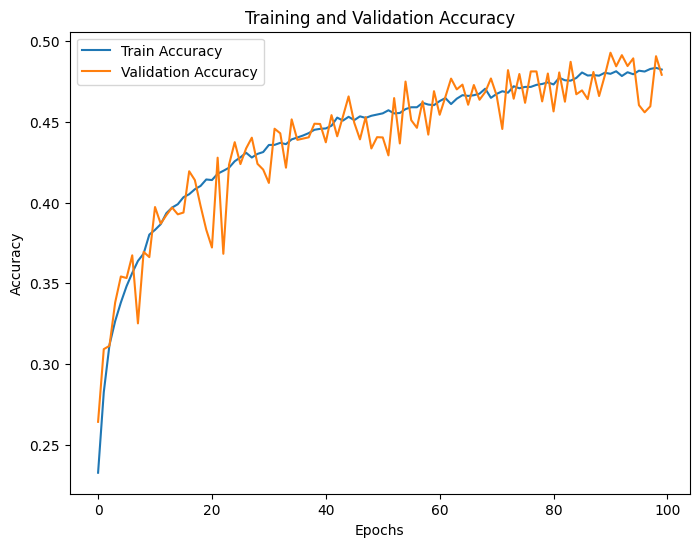

In [41]:
# Plot training and validation accuracy
# history = model.history
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()